Average over size distribution from laboratory measured data. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glitterin

In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions_glitterin"

/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [3]:
# class SizeContainer:
#     """
#     I will use r to be the radius of the particles. r here is in units of micron

#     The number of particles within the range r to r + dr is defined as 
#         n(r) dr
#     In this case, n(r) has units of counts per micron. 

#     Let y := log(r)
#     The experiment measures the number of particles within y to y + dy
#     That value is N_log_r which has units of counts

#     So these two are different quantities. Be careful
#     """

#     QUANTITY = ['log_r', 'N_log_r', 'S_log_r', 'V_log_r']

#     def __init__(self, name=None, log_r=None, N_log_r=None, S_log_r=None, V_log_r=None):
#         self.name = name
#         self.log_r = log_r
#         self.N_log_r = N_log_r
#         self.S_log_r = S_log_r
#         self.V_log_r = V_log_r

#     def x(self, w_micron):
#         """
#         the size parameter if we know the wavelength

#         Note that r in this object is in micron
#         """
#         return 2 * np.pi * self.r / w_micron

#     def resample(self, n=2):
#         """
#         for purposes of size averaging opacities, it may be useful to increase the sampling, especially for Mie theory with fine oscillations

#         Returns
#         -------
#             a SizeContainer object
#         """
#         new_n = int(np.ceil(n * len(self.log_r)))

#         new_grid = np.arange(new_n) / (new_n-1) * (len(self.log_r)-1)
#         log_r = np.interp(new_grid, np.arange(len(self.log_r)), self.log_r)

#         N_log_r = np.interp(log_r, self.log_r, self.N_log_r)

#         S_log_r = np.interp(log_r, self.log_r, self.S_log_r)

#         V_log_r = np.interp(log_r, self.log_r, self.V_log_r)

#         out = SizeContainer(name=self.name,
#             log_r=log_r,
#             N_log_r=N_log_r,
#             S_log_r=S_log_r,
#             V_log_r=V_log_r
#         )

#         return out

#     @property
#     def r(self):
#         """
#         instead of the logarithmic quantity, this is the actual size in microns
#         """
#         return 10**self.log_r

#     @property
#     def d_log_r(self):
#         """
#         calculate the bin size
#         We only know log_r defined on cells, so I need to do a bit of extrapolation
#         """
#         walls = np.zeros([len(self.log_r)+1])

#         walls[1:-1] = 0.5 * (self.log_r[1:] + self.log_r[:-1])

#         # extrapolate to first point
#         walls[0] = self.log_r[0] - (walls[1] - self.log_r[0])

#         # extrapolate to last point
#         walls[-1] = self.log_r[-1] + (self.log_r[-1] - walls[-2])

#         # now I can get the cell sizes
#         d_log_r = np.diff(walls)

#         return d_log_r

#     @property
#     def n_r(self):
#         """
#         This is the quantity related to the size distribution 

#         The log r of the database is log base 10

#         n(r) dr = N(log r) d log r
#             = N(log r) / r / ln(10) dr

#         in units of counts per unit length
#         """
#         return self.N_log_r / self.r / np.log(10.)

#     @property
#     def n_pwl(self):
#         """
#         The powerlow of the size density distribution
#         """
#         return np.log(self.n_r[1:] / self.n_r[:-1]) / np.log(self.r[1:] / self.r[:-1])

#     def __repr__(self):
#         txt = 'SizeContainer from gals_database.py'

#         return txt

#     def __str__(self):
#         txt = 'SizeContainer from gals_database.py'
#         if self.name is not None:
#             txt += 'name: {}\n'.format(self.name)

#         try:
#             txt += 'log_r range: [{}, ]\n'.format(self.log_r[0], self.log_r[-1])
#         except:
#             pass

#         return txt

In [4]:
# def read_gals_size_table(fname, skiprows=0, out_type='table'):
#     """
#     in most cases, we only have
#     log r, N(log r), S(log r), V(log r)

#     This will be the default file reader
#     """
#     # read the entire file
#     with open(fname, 'r') as f:
#         tab = np.loadtxt(fname, skiprows=skiprows)

#     if out_type == 'table':
#         return tab

#     elif out_type == 'container':
#         sizes = SizeContainer()
#         column_to_attribute = {0:'log_r', 1:'N_log_r', 2:'S_log_r', 3:'V_log_r'}
#         for icolumn in column_to_attribute:
#             ikey = column_to_attribute[icolumn]
#             setattr(sizes, ikey, tab[:,icolumn])

#         return sizes

In [5]:
# def average_over_size(C, N_log_r, d_log_r):
#     """
#     average a cross-sectional quantity over the size distribution

#     Let the number of particles in the range [r, r+dr] be n(r)dr
    
#     The contribution to the intensity using Cabs as an example: 
#         d I_nu = int n(r) Cabs dr B_nu
#     The averaged Cabs is the representative value for the number of particles that will produce the same level of d I_nu which means
#         avg(Cabs) int n(r) dr = int n(r) Cabs dr

#     This is the definition of avg(Cabs). It's equivalent for Cext and Csca. 

#     The scattering matrix quantities are in cross-section per steradian. 
#         d I_nu(Omega) = int n(r) Z11(theta) dr I_0 dOemga
#     This won't affect how we integrate. 

#     The experiments usually give n(log r) at locations in log r instead of the n(r) in r. 
#     Instead of converting to n(r), we should use this logarithmic sampling which helps with integration anyways. 

#     The database has a detailed explanation of what their measurements of N_log_r means. 
#     https://scattering.iaa.es/size

#     The total number of particles from r1 to r2 is: 

#         int_{r1}^{r2} n(r) dr = int_{log r1}^{log r2} N(log r) d log r

#     Their N_log_r is precisely N(log r) here. Apparently, their n(r) is normalized such that the integral is 1. 

#     The average quantity we need to assess is 
#         avg(Cabs) = int_{r1}^{r2} n(r) Cabs dr 
#             = int_{log r1}^{log r2} N(log r) Cabs d log r

#     Numerically, we can express this as 
#         avg(Cabs) = sum_i N(log_r)_i Cabs_i d log r_i

#     Parameters
#     ----------
#     C : ndarray
#         The first dimension is the size dimension to average over

#     Returns
#     -------

#     """
#     Ntot = np.sum(N_log_r * d_log_r)

#     dim = C.shape
#     if len(dim) == 1:
#         # we only have a 1d ndarray
#         Ctot = np.sum(C * N_log_r * d_log_r)
#     else:
#         expand = tuple(range(1, len(dim)))
#         Ctot = np.sum(C * np.expand_dims(N_log_r * d_log_r, axis=expand), axis=0)

#     avg = Ctot / Ntot

#     return avg


In [6]:
# Read size table
fname = 'sizes_feldspar.txt'
sizes = read_gals_size_table(fname, skiprows=2, out_type='container')

# Determine your wavelength
# There are 2 wavelengths from the lab, but it doesn't matter for the size distribution.
w_um = 0.4416 # [micron]

# This shows the actual sizes of the grains in um
print(sizes.r)

# size parameter for the laboratory grains
lab_x = sizes.x(w_um)

# Determine the refractive index based on the laboratory
# This is what I adopted
n = 1.5
k = 1e-4


[ 0.07585776  0.0851138   0.10471285  0.12022644  0.14454398  0.17378008
  0.20417379  0.24547089  0.28840315  0.34673685  0.40738028  0.48977882
  0.60255959  0.70794578  0.79432823  1.          1.14815362  1.41253754
  1.65958691  1.9498446   2.34422882  2.7542287   3.31131121  3.89045145
  4.67735141  5.49540874  6.45654229  7.94328235  9.54992586 10.96478196
 12.88249552]


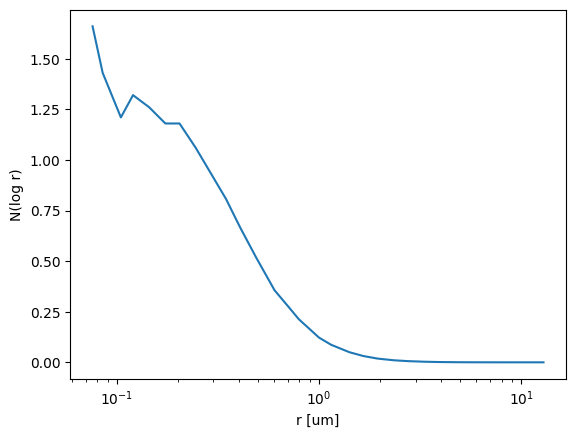

In [7]:
# You can plot the size distribution
plt.plot(sizes.r, sizes.N_log_r)
plt.xlabel('r [um]')
plt.ylabel('N(log r)')
plt.xscale('log')
#plt.yscale('log')


In [8]:
# Suppose you have your producer for the neural network just like in the Github Quickstart example
# Change the path

nndir = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/nnmodels/"

producer = glitterin.user.ScatteringProducer(nndir=nndir)

# Specify the desired scattering quantities
producer.setup(['Cext', 'Z11', 'Z12', 'Z22', 'Z33', 'Z34', 'Z44'])


/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded model for N12
Loaded model for N22
Loaded model for N33
Loaded model for Qext
Loaded model for N34
Loaded model for N11
Loaded model for N44
Loaded model for ems


In [11]:
# prepare inputs for the neural network
x_inp = lab_x
n_inp = n + np.zeros_like(x_inp)
k_inp = k + np.zeros_like(x_inp)
w_inp = w_um*1e4 + np.zeros_like(x_inp) # [cm]
theta = np.linspace(0, 180, 181)

# Now we can produce the scattering quantities for each grain size
mat = producer(x_inp, n_inp, k_inp, theta, w_inp, outtype='MuellerMatrix')



In [13]:
help(producer)

Help on ScatteringProducer in module glitterin.user object:

class ScatteringProducer(BasicProducer)
 |  ScatteringProducer(nndir=None)
 |  
 |  This will organize multiple TrainedModelProducer and convert to actual cross-section units
 |  
 |  Method resolution order:
 |      ScatteringProducer
 |      BasicProducer
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __call__(self, x, re_m, im_m, theta, w, xtype='enc', outtype='dict')
 |      This will produce the matrix in actual cross-sectional units if we know the wavelength. 
 |      Parameters
 |      ----------
 |      w : float, ndarray
 |          This should be a parameter that can multiply with xenc
 |          This better be in cm so that the cross-section will be in cm^2
 |      xenc
 |      re_m, im_m : 1d ndarray 
 |          These should be 1d arrays that match each other
 |      theta : 1d ndarray
 |          This is its own 1d array
 |      
 |      xtype : str
 |          'enc' = enclosed sphere
 |       

In [12]:
mat

In [10]:
# Average over grain size distribution 
Cext = average_over_size(mat.Cext, sizes.N_log_r, sizes.d_log_r)

# Scattering matrix
# The 1st dimension is the scattering angle, while my function requires the 1st dimension to be the size
Z11 = average_over_size(mat.Z11.T, sizes.N_log_r, sizes.d_log_r)
